# Student Data
This notebook analyizes pass/fail data for a class

Create and print a data right here in this Jupyter notebook

In [53]:
data = ([50,50,47,97,49,3,53,42,26,74,82,62,37,15,70,27,36,35,48,52,63,64])
print (data)


[50, 50, 47, 97, 49, 3, 53, 42, 26, 74, 82, 62, 37, 15, 70, 27, 36, 35, 48, 52, 63, 64]


Change this data to a numpy array which is better for numerical values

In [54]:
import numpy as np
grades = np.array(data)
print (grades)

[50 50 47 97 49  3 53 42 26 74 82 62 37 15 70 27 36 35 48 52 63 64]


This shows the shape of the data

In [55]:
grades.shape

(22,)

When numpy prints, it shows the type of numeric that it is like np.float64. This code elimates that

In [56]:
print(int(grades [5]))


3


Using the grades data, give me the average

In [57]:
grades.mean()

np.float64(49.18181818181818)

Bringing in another set of data (Study hours) and combining both data into one called Student_data. This forms two objects in one array. 2 rows in total

In [58]:
Study_hours = np.array([10.0, 11.5, 9.0, 16.0, 9.25, 1.0, 11.5, 9.0, 8.5, 14.5, 15.5, 13.75, 9.0, 8.0, 15.5, 8.0, 9.0, 6.0, 10.0, 12.0, 12.5, 12.0])

Student_data = np.array([Study_hours, grades])

This looks in the student data, finds the first row and returns the first col

In [59]:
Student_data[0][0]

np.float64(10.0)

This creates a variable which holds the avg study hours and avg grades of the student data. Then prints it on the screens and names them "Average Study Hours" and "Average Grades"

In [60]:
avg_study_hours = Student_data[0].mean()
avg_grades = Student_data[1].mean()
print("Average Study Hours:", avg_study_hours)
print("Average Grades:", avg_grades)

Average Study Hours: 10.522727272727273
Average Grades: 49.18181818181818


We import Pandas which has series and Dataframes. Series are like one row and one col. Datafram is a table. This creates 3 cols with Name, Study hours and Grades.

In [61]:
import pandas as pd

df_students = pd.DataFrame({'Name': ['Dan', 'Joann', 'Ebuka', 'Sarah', 'Michael', 'Emily', 'David', 'Jessica', 'Daniel', 'Laura', 'James', 'Sophia', 'Robert', 'Olivia', 'William', 'Ava', 'Joseph', 'Isabella', 'Charles', 'Mia', 'Thomas', 'Amelia'],
                                'Study_hours': Student_data[0],
                                'Grades': Student_data[1]})
print(df_students)

        Name  Study_hours  Grades
0        Dan        10.00    50.0
1      Joann        11.50    50.0
2      Ebuka         9.00    47.0
3      Sarah        16.00    97.0
4    Michael         9.25    49.0
5      Emily         1.00     3.0
6      David        11.50    53.0
7    Jessica         9.00    42.0
8     Daniel         8.50    26.0
9      Laura        14.50    74.0
10     James        15.50    82.0
11    Sophia        13.75    62.0
12    Robert         9.00    37.0
13    Olivia         8.00    15.0
14   William        15.50    70.0
15       Ava         8.00    27.0
16    Joseph         9.00    36.0
17  Isabella         6.00    35.0
18   Charles        10.00    48.0
19       Mia        12.00    52.0
20    Thomas        12.50    63.0
21    Amelia        12.00    64.0


Returns rows where the study hours is greater than 10hours

In [62]:
df_students[df_students.Study_hours > 10]

,Name,Study_hours,Grades
1,Joann,11.50,50.0
3,Sarah,16.00,97.0
6,David,11.50,53.0
9,Laura,14.50,74.0
10,James,15.50,82.0
11,Sophia,13.75,62.0
14,William,15.50,70.0
19,Mia,12.00,52.0
20,Thomas,12.50,63.0
21,Amelia,12.00,64.0


Instead of creating data here, I uploaded a csv file from my computer and had it read

In [63]:
import pandas as pd

df_students = pd.read_csv("Grades_data.csv")



This prints the dataframe without using "Print"

In [64]:
df_students

,Name,StudyHours,Grade
0,Alice,2.5,67.0
1,Brian,4.0,78.0
2,Cynthia,1.5,55.0
3,Daniel,3.2,72.0
4,Esther,5.0,88.0
5,Frank,2.0,61.0
6,Grace,6.0,92.0
7,Henry,3.8,80.0
8,Irene,4.5,NaN
9,John,1.0,50.0


This data had missing values. This find them and where they are

In [65]:
df_students.isnull().sum()

Name          0
StudyHours    1
Grade         2
dtype: int64

This fills in the missing values which happened to be numbers with the average of that col

In [66]:
df_students.StudyHours = df_students.StudyHours.fillna(df_students.StudyHours.mean())


This drops the rows of the missing values entirely. This is more pratical. If we had said axis = 1, it will drop a whole col of data and that would be wrong

In [67]:
df_students = df_students.dropna(axis=0)

Create variables for the average study hour and grade and print them

In [68]:
mean_study = df_students.StudyHours.mean()
mean_grade = df_students.Grade.mean()
print("Average Study Hours:", mean_study)
print("Average Grade:", mean_grade)

Average Study Hours: 3.462619047619048
Average Grade: 74.35


What is the average grade of those whose study hours is above the average study hours

In [69]:
df_students[df_students.StudyHours > mean_study].Grade.mean()

np.float64(85.0)

Create 2 dataframes called Passed and Failed which stores the students who got above and below 60 respectively

In [70]:
Passed = df_students[df_students.Grade >= 60]
Failed = df_students[df_students.Grade < 60]

In [71]:
Passed

,Name,StudyHours,Grade
0,Alice,2.500000,67.0
1,Brian,4.000000,78.0
3,Daniel,3.200000,72.0
4,Esther,5.000000,88.0
5,Frank,2.000000,61.0
6,Grace,6.000000,92.0
7,Henry,3.800000,80.0
10,Karen,2.800000,70.0
11,Leo,3.000000,74.0
12,Maria,5.500000,90.0


Instead of creating new dataframes for passed and failed, create a series and add to our existing dataframe. Title the col Passed and return a True or False if they passed or failed

In [72]:
passed = pd.Series(df_students.Grade >= 60)
df_students = pd.concat([df_students, passed.rename('Passed')], axis=1)
print(df_students)

       Name  StudyHours  Grade  Passed
0     Alice    2.500000   67.0    True
1     Brian    4.000000   78.0    True
2   Cynthia    1.500000   55.0   False
3    Daniel    3.200000   72.0    True
4    Esther    5.000000   88.0    True
5     Frank    2.000000   61.0    True
6     Grace    6.000000   92.0    True
7     Henry    3.800000   80.0    True
9      John    1.000000   50.0   False
10    Karen    2.800000   70.0    True
11      Leo    3.000000   74.0    True
12    Maria    5.500000   90.0    True
14   Olivia    4.800000   87.0    True
15     Paul    3.600000   79.0    True
16    Queen    1.800000   58.0   False
17  Richard    3.452381   73.0    True
18    Sarah    4.200000   82.0    True
19   Thomas    5.300000   89.0    True
20     Uche    3.400000   76.0    True
21   Vivian    2.400000   66.0    True


Using the groupby function return the count of true and false in the new col

In [73]:
df_students.groupby('Passed').Grade.count()

Passed
False     3
True     17
Name: Grade, dtype: int64

What is the avg study hours and grade of those who passed and print them

In [74]:
PassedAvgStudyHours = df_students[df_students.Passed == True].StudyHours.mean()
PassedAvgGrade = df_students[df_students.Passed == True].Grade.mean()

In [75]:
print("Average Grade of Passed Students:", Passed.Grade.mean())
print("Average Study Hours of Passed Students:", Passed.StudyHours.mean())

Average Grade of Passed Students: 77.88235294117646
Average Study Hours of Passed Students: 3.8207282913165264


What is the avg study hours and grade of those who failed and print them

In [76]:
FailedAvgStudyHours = df_students[df_students.Passed == False].StudyHours.mean()
FailedAvgGrade = df_students[df_students.Passed == False].Grade.mean()
print("Average Grade of Failed Students:", Failed.Grade.mean())
print("Average Study Hours of Failed Students:", Failed.StudyHours.mean())

Average Grade of Failed Students: 54.333333333333336
Average Study Hours of Failed Students: 1.4333333333333333


This does the same but in a simpler version using the groupby function. What is the avg study hours and grade of those who passed/failed and print them

In [77]:
df_students.groupby('Passed')[['Grade', 'StudyHours']].mean()

,Grade,StudyHours
Passed,,
False,54.333333,1.433333
True,77.882353,3.820728


Sort in ascending or decending order

In [78]:
df_students= df_students.sort_values(by='Grade', ascending=True)
print(df_students)

       Name  StudyHours  Grade  Passed
9      John    1.000000   50.0   False
2   Cynthia    1.500000   55.0   False
16    Queen    1.800000   58.0   False
5     Frank    2.000000   61.0    True
21   Vivian    2.400000   66.0    True
0     Alice    2.500000   67.0    True
10    Karen    2.800000   70.0    True
3    Daniel    3.200000   72.0    True
17  Richard    3.452381   73.0    True
11      Leo    3.000000   74.0    True
20     Uche    3.400000   76.0    True
1     Brian    4.000000   78.0    True
15     Paul    3.600000   79.0    True
7     Henry    3.800000   80.0    True
18    Sarah    4.200000   82.0    True
14   Olivia    4.800000   87.0    True
4    Esther    5.000000   88.0    True
19   Thomas    5.300000   89.0    True
12    Maria    5.500000   90.0    True
6     Grace    6.000000   92.0    True


Creating a barchart which is used by data analysts to understand the distribution of data

<function matplotlib.pyplot.show(close=None, block=None)>

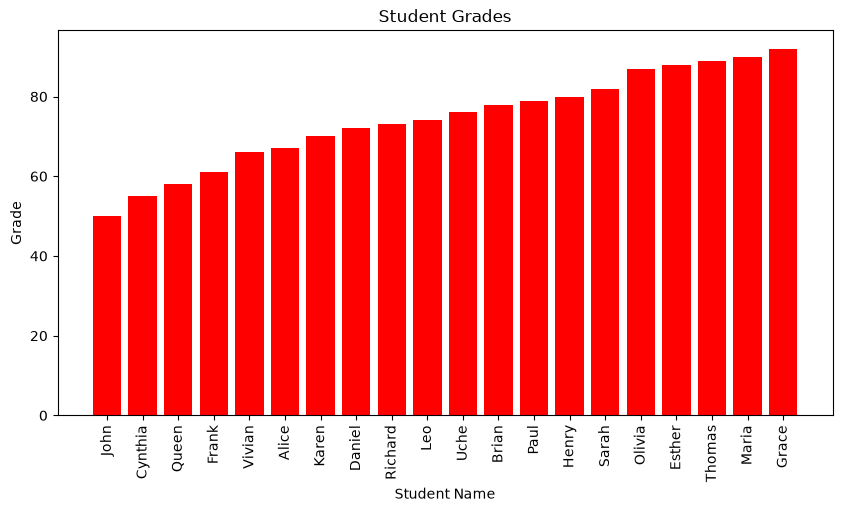

In [79]:
from matplotlib import pyplot as plt
fig = plt.figure(figsize=(10, 5))
plt.bar(df_students.Name, df_students.Grade, color='red')
plt.xlabel('Student Name')
plt.ylabel('Grade')
plt.title('Student Grades')
plt.xticks(rotation=90)
plt.show

Creating a barchart which is used by data analysts to understand the distribution of data

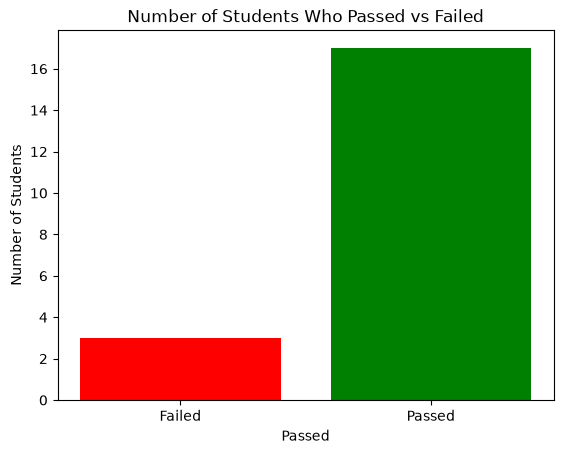

In [80]:
passes_count = df_students.Passed.value_counts()
plt.bar(passes_count.index, passes_count.values, color=['green', 'red'])
plt.xlabel('Passed')
plt.ylabel('Number of Students')
plt.title('Number of Students Who Passed vs Failed')
plt.xticks([0, 1], ['Failed', 'Passed'])
plt.show()

Creating a piechart which is used by data analysts to understand the distribution of data

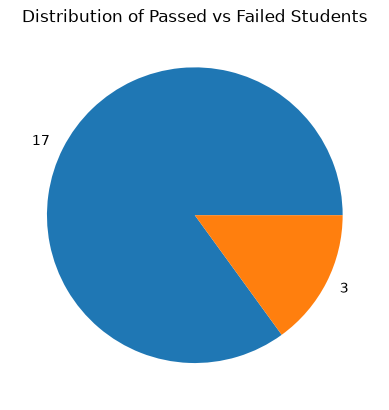

In [81]:
passes_count = df_students.Passed.value_counts()
plt.pie(passes_count, labels=passes_count)
plt.title('Distribution of Passed vs Failed Students')
plt.show()

In [82]:
passes_count


Passed
True     17
False     3
Name: count, dtype: int64

Creating a scatter plot which is used by data analysts to understand the distribution of data. Plots are builtin in pandas so we don't need to improt matplotlid. 

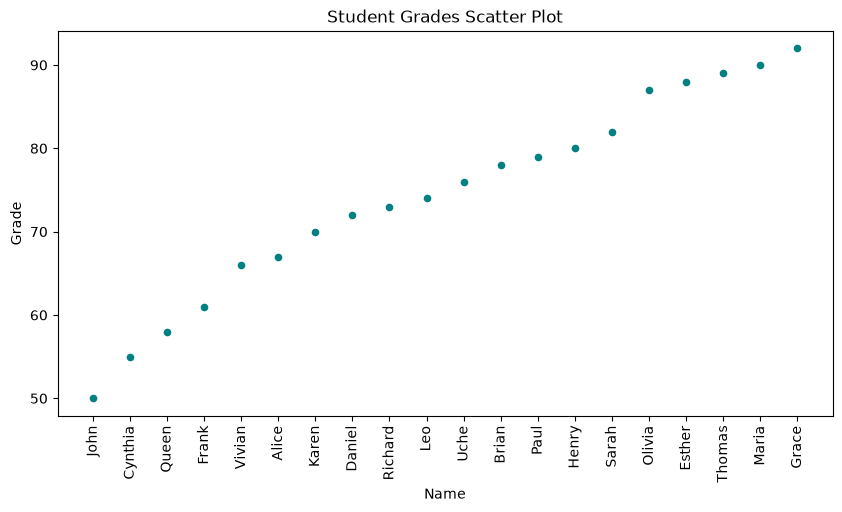

In [83]:
df_students.plot(x='Name', y='Grade', kind='scatter', figsize=(10, 5), color='teal',title='Student Grades Scatter Plot')
plt.xticks(rotation=90)
plt.show()

Creating a histogram which is used by data analysts to understand the distribution of data

Minimum Grade: 50.0
Maximum Grade: 92.0
Mean Grade: 74.35
Median Grade: 75.0
Mode Grade: 50.0


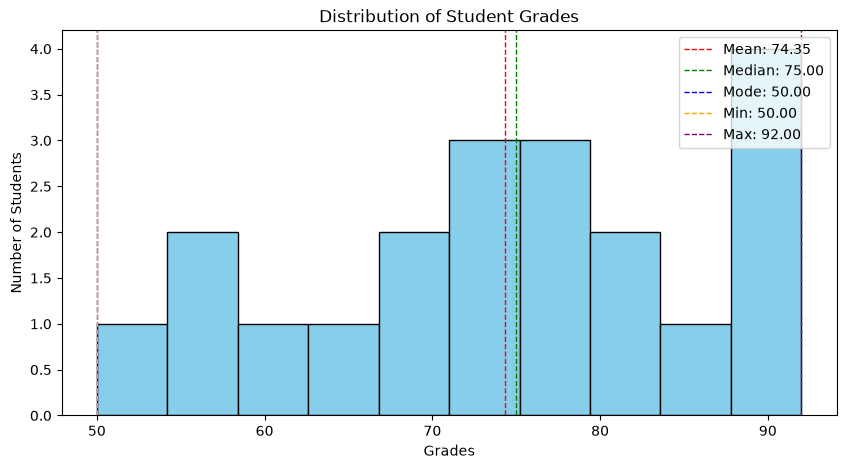

In [84]:
grades = df_students.Grade

min_grade = df_students.Grade.min()
max_grade = df_students.Grade.max()
mean_grade = df_students.Grade.mean()
median_grade = df_students.Grade.median()
mode_grade = df_students.Grade.mode()[0]
print("Minimum Grade:", min_grade)
print("Maximum Grade:", max_grade)
print("Mean Grade:", mean_grade)
print("Median Grade:", median_grade)
print("Mode Grade:", mode_grade)

fig = plt.figure(figsize=(10, 5))
plt.hist(grades, bins=10, color='skyblue', edgecolor='black')

plt.axvline(mean_grade, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_grade:.2f}')
plt.axvline(median_grade, color='green', linestyle='dashed', linewidth=1, label=f'Median: {median_grade:.2f}')
plt.axvline(mode_grade, color='blue', linestyle='dashed', linewidth=1, label=f'Mode: {mode_grade:.2f}')
plt.axvline(min_grade, color='orange', linestyle='dashed', linewidth=1, label=f'Min: {min_grade:.2f}')
plt.axvline(max_grade, color='purple', linestyle='dashed', linewidth=1, label=f'Max: {max_grade:.2f}')
plt.legend()

plt.xlabel('Grades')
plt.ylabel('Number of Students')
plt.title('Distribution of Student Grades')
plt.show()

Creating a boxplot which is used by data analysts to understand the distribution of data

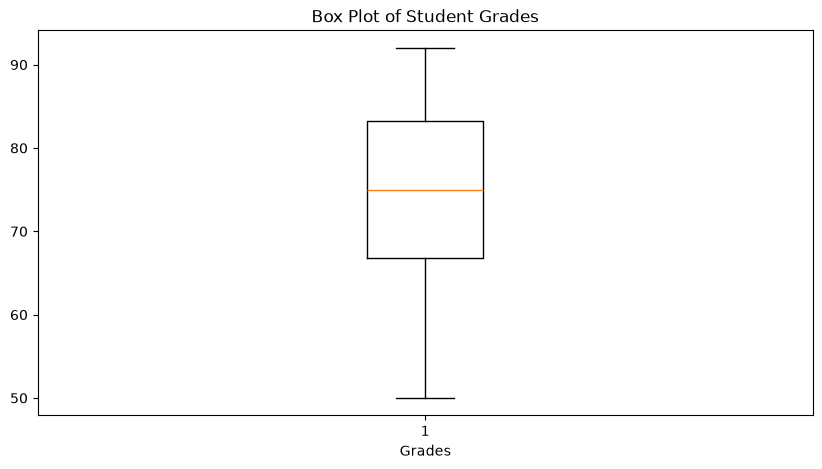

In [85]:
grades = df_students.Grade
fig = plt.figure(figsize=(10, 5))
plt.boxplot(grades)
plt.xlabel('Grades')
plt.title('Box Plot of Student Grades')
plt.show()

Creating a density plot inside a function. This is a probability density AKA a bell curve

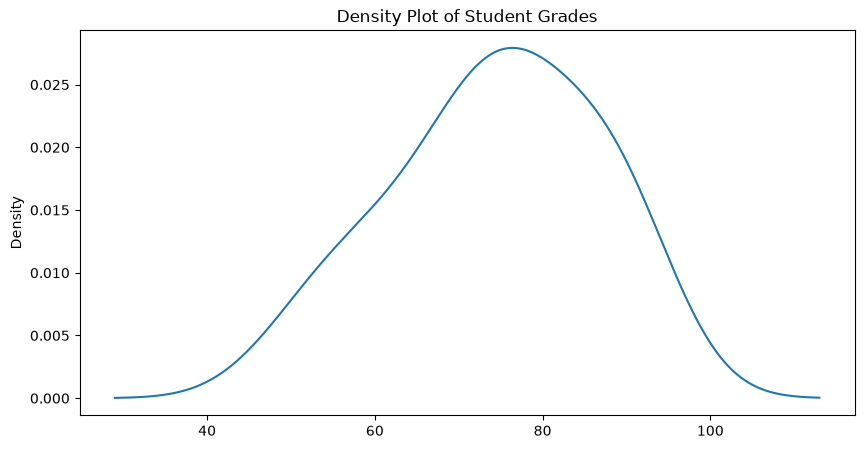

In [86]:
def show_density(data):
    fig = plt.figure(figsize=(10, 5))
    data.plot.density()
    plt.title('Density Plot of Student Grades')
    plt.show()
show_density(df_students.Grade)

In [87]:
df_students.describe()


,StudyHours,Grade
count,20.000000,20.00000
mean,3.462619,74.35000
std,1.389516,12.15806
min,1.000000,50.00000
25%,2.475000,66.75000
50%,3.426190,75.00000
75%,4.350000,83.25000
max,6.000000,92.00000


New variable where study hours is greater than 1

In [88]:
df_sample = df_students[df_students.StudyHours > 1]
df_sample

,Name,StudyHours,Grade,Passed
2,Cynthia,1.500000,55.0,False
16,Queen,1.800000,58.0,False
5,Frank,2.000000,61.0,True
21,Vivian,2.400000,66.0,True
0,Alice,2.500000,67.0,True
10,Karen,2.800000,70.0,True
3,Daniel,3.200000,72.0,True
17,Richard,3.452381,73.0,True
11,Leo,3.000000,74.0,True
20,Uche,3.400000,76.0,True


We are comparing numeric value(study hours) to a non-numeric value (Passed) to see the correlation

<Axes: title={'center': 'StudyHours'}, xlabel='Passed'>

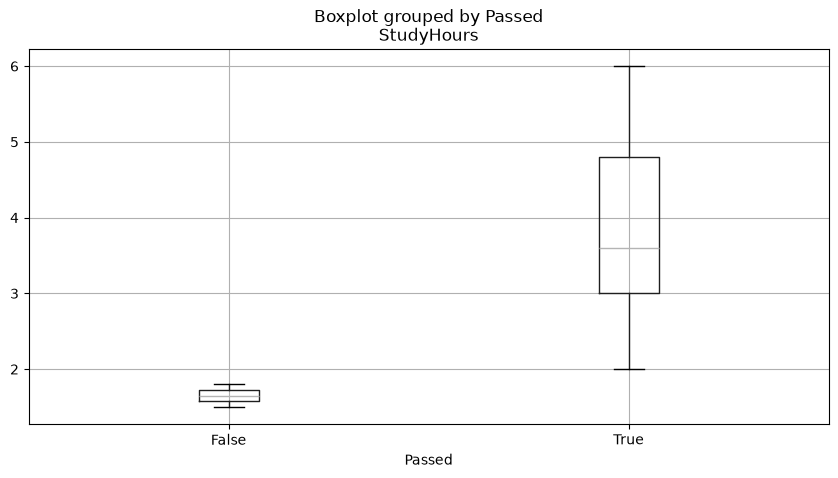

In [89]:
df_sample.boxplot(column='StudyHours', by='Passed', figsize=(10, 5))

Comparing study hours to grade but they are not on the same scale. The grades are getting up tp 100 while the study hours are on a different scale.

<Axes: title={'center': 'Grades and Study Hours of Sample Students'}, xlabel='Name'>

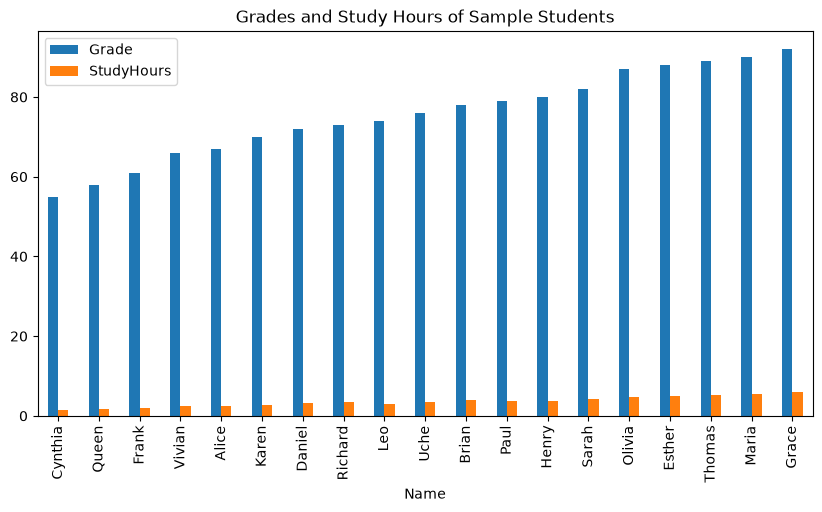

In [90]:
df_sample.plot(x='Name', y=['Grade', 'StudyHours'], kind='bar', figsize=(10, 5), title='Grades and Study Hours of Sample Students')

Using MinMaxSCaler we can tell that there is a direct colrrolation between study hours and grades

<Axes: title={'center': 'Normalized Grades and Study Hours of Students'}, xlabel='Name'>

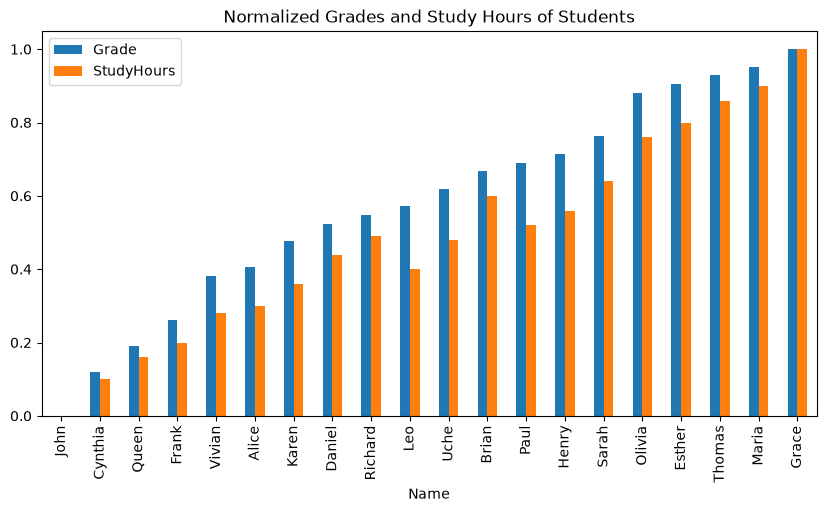

In [91]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_normalized = df_students.copy()
df_normalized[['Grade', 'StudyHours']] = scaler.fit_transform(df_normalized[['Grade', 'StudyHours']])
df_normalized.plot(x='Name', y=['Grade', 'StudyHours'], kind='bar', figsize=(10, 5), title='Normalized Grades and Study Hours of Students')

There is a strong correlation between studtHours and Grades

In [92]:
df_normalized.Grade.corr(df_normalized.StudyHours)

np.float64(0.9838832651615914)

Scattered plot and a linear regression line. A code to predict grade of a student given the study hour. 

<Axes: xlabel='StudyHours', ylabel='Grade'>

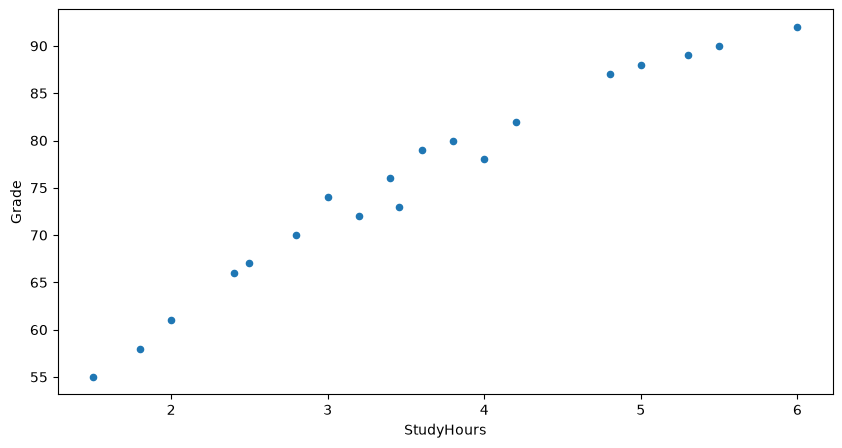

In [93]:
df_sample.plot.scatter(x='StudyHours', y='Grade', figsize=(10, 5))

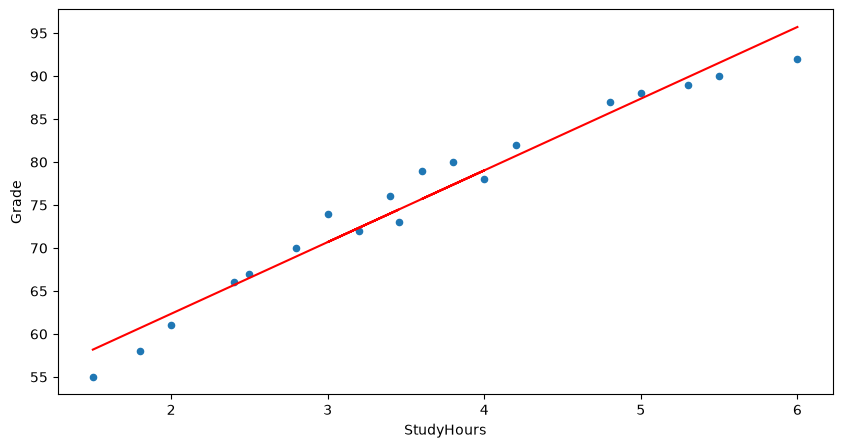

Slope (m): 8.339376129183961
Intercept (b): 45.674617027670756


In [97]:
from scipy import stats
df_regression = df_sample[['StudyHours', 'Grade']].copy()
stats.linregress(df_regression['StudyHours'], df_regression['Grade'])
m, b, r, p, se = stats.linregress(df_regression['StudyHours'], df_regression['Grade'])
df_regression['fx'] = (m * df_regression['StudyHours']) + b
df_regression['error'] = df_regression['fx'] - df_regression['Grade']
df_regression.plot.scatter(x='StudyHours', y='Grade', figsize=(10, 5))
plt.plot(df_regression['StudyHours'], df_regression['fx'], color='red')
plt.show()
print(f"Slope (m): {m}")
print(f"Intercept (b): {b}")


In [100]:
def predict_grade(x):
    m = 8.3394
    b = 45.6746
    return (m * x) + b

prediction = predict_grade(6)
print(f"Predicted Grade for 10 Study Hours: {prediction:.2f}")

Predicted Grade for 10 Study Hours: 95.71
